In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.utils import Sequence
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split

2026-04-11 23:58:50.984348: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775951931.171913      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775951931.227844      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775951931.690466      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775951931.690510      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775951931.690515      55 computation_placer.cc:177] computation placer alr

In [2]:
IMG_DIR = "/kaggle/input/datasets/theredlad/pannuke-dataset-experimental-data/train/images"
MASK_DIR = "/kaggle/input/datasets/theredlad/pannuke-dataset-experimental-data/train/masks"

image_files = sorted(os.listdir(IMG_DIR))
mask_files = sorted(os.listdir(MASK_DIR))

print("Total images:", len(image_files))
print("Total masks:", len(mask_files))

Total images: 6716
Total masks: 6716


In [3]:
import pandas as pd
sizes = []

for file in image_files[:200]:
    img = cv2.imread(os.path.join(IMG_DIR, file))
    sizes.append(img.shape)

pd.Series(sizes).value_counts()

(256, 256, 3)    200
Name: count, dtype: int64

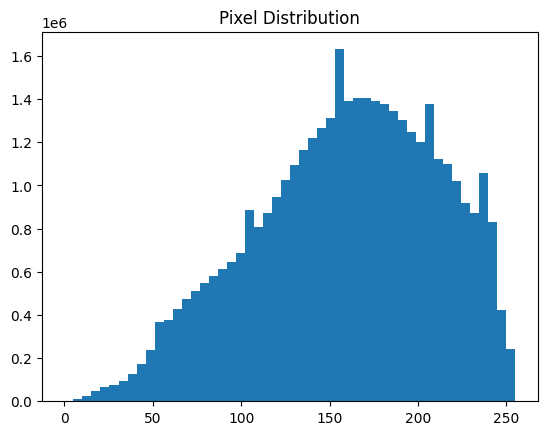

In [4]:
pixels = []

for file in image_files[:200]:
    img = cv2.imread(os.path.join(IMG_DIR, file))
    pixels.extend(img.flatten())

plt.hist(pixels, bins=50)
plt.title("Pixel Distribution")
plt.show()

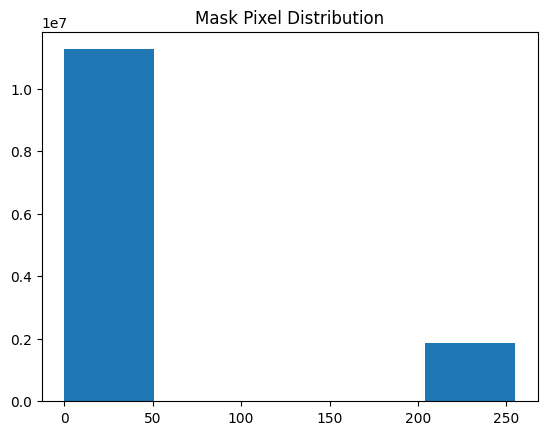

In [5]:
mask_pixels = []

for file in mask_files[:200]:
    mask = cv2.imread(os.path.join(MASK_DIR, file), 0)
    mask_pixels.extend(mask.flatten())

plt.hist(mask_pixels, bins=5)
plt.title("Mask Pixel Distribution")
plt.show()

In [6]:
foreground = 0
total = 0

for file in mask_files[:200]:
    mask = cv2.imread(os.path.join(MASK_DIR, file), 0)
    foreground += np.sum(mask > 0)
    total += mask.size

print("Foreground ratio:", foreground / total)

Foreground ratio: 0.141387939453125


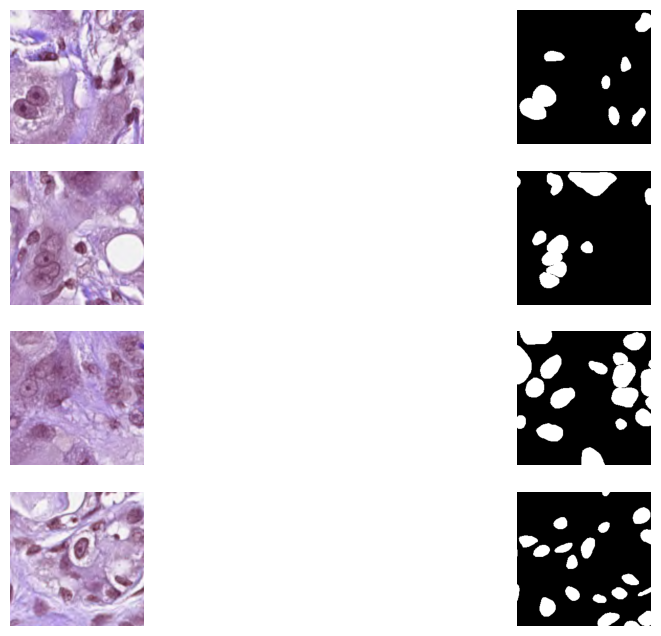

In [7]:
plt.figure(figsize=(12,8))

for i in range(4):

    img = cv2.imread(os.path.join(IMG_DIR, image_files[i]))
    mask = cv2.imread(os.path.join(MASK_DIR, mask_files[i]), 0)

    plt.subplot(4,2,2*i+1)
    plt.imshow(img[:,:,::-1])
    plt.axis("off")

    plt.subplot(4,2,2*i+2)
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

plt.show()

In [8]:
train_imgs, val_imgs = train_test_split(
    image_files,
    test_size=0.2,
    random_state=42
)

train_masks, val_masks = train_test_split(
    mask_files,
    test_size=0.2,
    random_state=42
)

In [9]:
IMG_SIZE = 128
BATCH_SIZE = 4

In [17]:
from tensorflow.keras.utils import Sequence
import numpy as np
import cv2
import os

class DataGenerator(Sequence):

    def __init__(self, img_list, mask_list, **kwargs):

        super().__init__(**kwargs)

        self.img_list = img_list
        self.mask_list = mask_list

    def __len__(self):

        return len(self.img_list) // BATCH_SIZE

    def __getitem__(self, index):

        batch_imgs = self.img_list[
            index*BATCH_SIZE:(index+1)*BATCH_SIZE
        ]

        batch_masks = self.mask_list[
            index*BATCH_SIZE:(index+1)*BATCH_SIZE
        ]

        images = []
        masks = []

        for img_file, mask_file in zip(batch_imgs, batch_masks):

            # ---------- Load image ----------
            img = cv2.imread(os.path.join(IMG_DIR, img_file))
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img.astype(np.float32) / 255.0

            # ---------- Load mask ----------
            mask = cv2.imread(
                os.path.join(MASK_DIR, mask_file),
                cv2.IMREAD_GRAYSCALE
            )

            mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE))
            mask = mask.astype(np.float32) / 255.0

            # ---------- Augmentation ----------
            if np.random.rand() > 0.5:

                img = cv2.flip(img, 1)
                mask = cv2.flip(mask, 1)

            if np.random.rand() > 0.5:

                angle = np.random.randint(-15, 15)

                M = cv2.getRotationMatrix2D(
                    (IMG_SIZE//2, IMG_SIZE//2),
                    angle,
                    1
                )

                img = cv2.warpAffine(
                    img,
                    M,
                    (IMG_SIZE, IMG_SIZE)
                )

                mask = cv2.warpAffine(
                    mask,
                    M,
                    (IMG_SIZE, IMG_SIZE)
                )

            # ---------- Fix mask shape ----------
            mask = np.expand_dims(mask, axis=-1)

            images.append(img)
            masks.append(mask)

        return (
            np.array(images, dtype=np.float32),
            np.array(masks, dtype=np.float32)
        )

In [18]:
train_gen = DataGenerator(train_imgs, train_masks)
val_gen = DataGenerator(val_imgs, val_masks)

In [19]:
def dice_coef(y_true, y_pred):

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    smooth = 1e-6

    intersection = tf.reduce_sum(y_true * y_pred)

    return (2. * intersection + smooth) / (
        tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth
    )


def hybrid_loss(y_true, y_pred):

    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)

    return bce + (1 - dice_coef(y_true, y_pred))

In [20]:
def attention_block(x, g, filters):

    theta_x = layers.Conv2D(filters, 1)(x)
    phi_g = layers.Conv2D(filters, 1)(g)

    add = layers.Add()([theta_x, phi_g])
    act = layers.Activation("relu")(add)

    psi = layers.Conv2D(1, 1)(act)
    psi = layers.Activation("sigmoid")(psi)

    return layers.Multiply()([x, psi])

In [21]:
def Attention_UNet(input_shape=(128,128,3)):

    inputs = layers.Input(input_shape)

    c1 = layers.Conv2D(32,3,activation="relu",padding="same")(inputs)
    c1 = layers.Conv2D(32,3,activation="relu",padding="same")(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64,3,activation="relu",padding="same")(p1)
    c2 = layers.Conv2D(64,3,activation="relu",padding="same")(c2)
    p2 = layers.MaxPooling2D()(c2)

    c3 = layers.Conv2D(128,3,activation="relu",padding="same")(p2)
    c3 = layers.Conv2D(128,3,activation="relu",padding="same")(c3)

    u4 = layers.UpSampling2D()(c3)
    att4 = attention_block(c2, u4, 64)
    u4 = layers.concatenate([u4, att4])
    c4 = layers.Conv2D(64,3,activation="relu",padding="same")(u4)

    u5 = layers.UpSampling2D()(c4)
    att5 = attention_block(c1, u5, 32)
    u5 = layers.concatenate([u5, att5])
    c5 = layers.Conv2D(32,3,activation="relu",padding="same")(u5)

    outputs = layers.Conv2D(1,1,activation="sigmoid")(c5)

    return models.Model(inputs, outputs)

In [22]:
model = Attention_UNet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=hybrid_loss,
    metrics=[dice_coef]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_15[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 64, 64,    │          0 │ conv2d_16[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_17[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 32, 32,    │          0 │ conv2d_18[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_3[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_19[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 64, 64,    │          0 │ conv2d_20[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │      4,160 │ conv2d_18[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 64, 64,    │      8,256 │ up_sampling2d_2[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 64,    │          0 │ conv2d_21[0][0],  │
│                     │ 64)               │            │ conv2d_22[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 64, 64,    │          0 │ add_2[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64, 1) │         65 │ activation_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 64, 64, 1) │          0 │ conv2d_23[0][0]   │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 64, 64,    │          0 │ conv2d_18[0][0],  │
│ (Multiply)          │ 64)               │            │ activation_5[0][

 Total params: 441,027 (1.68 MB)

 Trainable params: 441,027 (1.68 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=25
)

Epoch 1/25


I0000 00:00:1775952232.491906     145 service.cc:152] XLA service 0x7ae95c0023d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775952232.491957     145 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775952232.491964     145 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775952233.373402     145 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-12 00:03:56.223668: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 00:03:56.521805: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-12 00:03:56.926337: E external/local_xl

   3/1343 ━━━━━━━━━━━━━━━━━━━━ 1:04 48ms/step - dice_coef: 0.2747 - loss: 1.4190  

I0000 00:00:1775952242.344861     145 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1343/1343 ━━━━━━━━━━━━━━━━━━━━ 207s 143ms/step - dice_coef: 0.4804 - loss: 0.8436 - val_dice_coef: 0.6596 - val_loss: 0.5644
Epoch 2/25
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step - dice_coef: 0.6616 - loss: 0.5714 - val_dice_coef: 0.6988 - val_loss: 0.5124
Epoch 3/25
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 34s 26ms/step - dice_coef: 0.6983 - loss: 0.5126 - val_dice_coef: 0.7166 - val_loss: 0.4764
Epoch 4/25
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - dice_coef: 0.7156 - loss: 0.4816 - val_dice_coef: 0.7222 - val_loss: 0.4569
Epoch 5/25
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - dice_coef: 0.7277 - loss: 0.4617 - val_dice_coef: 0.7381 - val_loss: 0.4511
Epoch 6/25
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - dice_coef: 0.7413 - loss: 0.4426 - val_dice_coef: 0.7336 - val_loss: 0.4433
Epoch 7/25
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - dice_coef: 0.7444 - loss: 0.4350 - val_dice_coef: 0.7496 - val_loss: 0.4204
Epoch 8/25
1343/1343 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - dice_coef: 0.

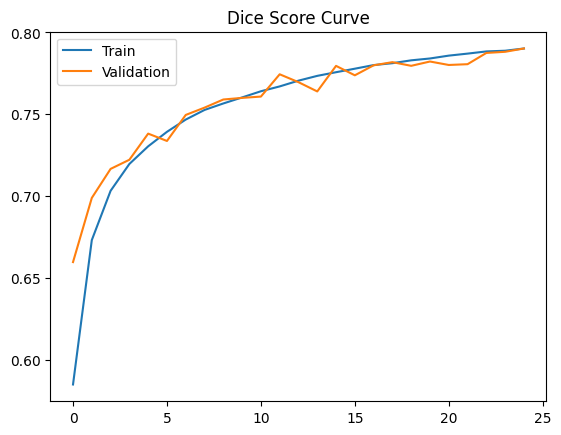

In [24]:
plt.plot(history.history["dice_coef"])
plt.plot(history.history["val_dice_coef"])

plt.title("Dice Score Curve")
plt.legend(["Train","Validation"])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 779ms/step


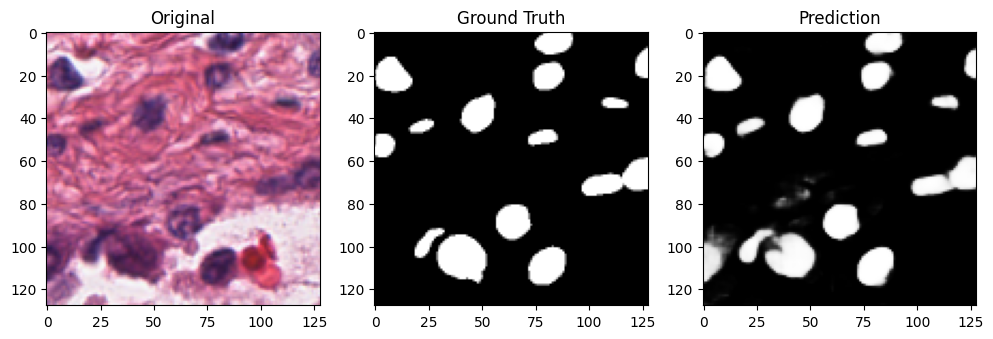

In [25]:
sample_batch = val_gen[0]

pred = model.predict(sample_batch[0])

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(sample_batch[0][0])
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(sample_batch[1][0].squeeze(), cmap="gray")
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(pred[0].squeeze(), cmap="gray")
plt.title("Prediction")

plt.show()

In [26]:
model.save("attention_unet_pannuke.keras")